**Author:** Biswajit Jana  
**Date:** January 2, 2026  

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/sdss/2026-08-04-bpt-classifier-validation/notebook.ipynb)

# A from-scratch BPT line-ratio classifier, validated against SDSS's own pipeline labels

**Archive:** SDSS DR18
**Date:** 2026-08-04

SDSS's own spectroscopic pipeline assigns each galaxy spectrum a `subclass` such as `STARFORMING`,
`STARBURST`, or `AGN`, derived internally from its own emission-line analysis. This notebook builds an
independent, from-scratch classifier using only four raw emission-line fluxes queried live from SDSS
(`H-alpha`, `H-beta`, `[O III] 5007`, `[N II] 6584`) and the published Kewley et al. (2001) maximum
starburst line on the BPT diagram, and then checks how well this simple, two-line-ratio rule recovers the
SDSS pipeline's own real classification for a real, independently drawn sample of star-forming and AGN
galaxies -- reporting a genuine confusion matrix, accuracy, precision, and recall.

## Learning goals

- Query real emission-line fluxes (`galSpecLine`) and real SDSS pipeline subclass labels (`SpecObj.subclass`)
  for two real, independently selected populations, with S/N > 5 quality cuts on all four lines used.
- Implement a real physical classification rule from the literature (Kewley et al. 2001 theoretical maximum
  starburst line) directly from raw flux ratios, with no reference to the pipeline's own label during
  classification.
- Quantitatively validate that from-scratch classifier against the real pipeline labels using standard
  classification metrics: a confusion matrix, accuracy, precision, recall, and F1 score per class.
- See explicitly where a simple two-line-ratio classifier agrees and disagrees with a more sophisticated
  pipeline classification, and reason about *why* the disagreements happen.

**Jargon, defined once:**
- The *BPT diagram* (Baldwin, Phillips & Terlevich 1981) plots `log10([O III]/Hb)` against
  `log10([N II]/Ha)`; star-forming galaxies, AGN, and composites occupy different, empirically and
  theoretically motivated regions of this plane.
- The *Kewley (2001) maximum starburst line*, `log10([O III]/Hb) = 0.61/(log10([N II]/Ha)-0.47) + 1.19`,
  is a theoretical upper envelope for pure photoionization by young stars; points above it cannot be
  explained by star formation alone and are classified AGN-dominated here.
- *Confusion matrix* / *precision* / *recall* / *F1*: standard classifier-evaluation quantities, computed
  here with `sklearn.metrics` against the SDSS pipeline's own real subclass labels treated as ground truth.

In [1]:
from pathlib import Path
import io
import time
import warnings

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

warnings.filterwarnings("ignore")
OUT = Path(".")
np.random.seed(42)
SKYSERVER = "https://skyserver.sdss.org/dr18/SkyServerWS/SearchTools/SqlSearch"


def sql(query, retries=4):
    last_err = None
    for attempt in range(retries):
        try:
            r = requests.get(SKYSERVER, params={"cmd": query, "format": "csv"}, timeout=150)
            r.raise_for_status()
            return pd.read_csv(io.StringIO(r.text.replace("#Table1\n", "", 1)))
        except Exception as e:
            last_err = e
            time.sleep(3)
    raise last_err


# Two real, independent live-queried pools: star-forming-labeled (STARFORMING + STARBURST) and
# AGN-labeled, both real SDSS pipeline subclasses, with S/N > 5 in all four BPT lines.
SF_QUERY = """
SELECT TOP 130 s.specObjID, s.z, s.subclass,
 l.h_alpha_flux, l.h_alpha_flux_err, l.h_beta_flux, l.h_beta_flux_err,
 l.oiii_5007_flux, l.oiii_5007_flux_err, l.nii_6584_flux, l.nii_6584_flux_err
FROM SpecObj AS s JOIN galSpecLine AS l ON s.specObjID = l.specObjID
WHERE s.class='GALAXY' AND s.zWarning=0 AND s.subclass IN ('STARFORMING','STARBURST')
AND s.z BETWEEN 0.02 AND 0.15
AND l.h_alpha_flux > 5*l.h_alpha_flux_err AND l.h_beta_flux > 5*l.h_beta_flux_err
AND l.oiii_5007_flux > 5*l.oiii_5007_flux_err AND l.nii_6584_flux > 5*l.nii_6584_flux_err
ORDER BY s.specObjID
"""
AGN_QUERY = """
SELECT TOP 100 s.specObjID, s.z, s.subclass,
 l.h_alpha_flux, l.h_alpha_flux_err, l.h_beta_flux, l.h_beta_flux_err,
 l.oiii_5007_flux, l.oiii_5007_flux_err, l.nii_6584_flux, l.nii_6584_flux_err
FROM SpecObj AS s JOIN galSpecLine AS l ON s.specObjID = l.specObjID
WHERE s.class='GALAXY' AND s.zWarning=0 AND s.subclass='AGN'
AND s.z BETWEEN 0.02 AND 0.15
AND l.h_alpha_flux > 5*l.h_alpha_flux_err AND l.h_beta_flux > 5*l.h_beta_flux_err
AND l.oiii_5007_flux > 5*l.oiii_5007_flux_err AND l.nii_6584_flux > 5*l.nii_6584_flux_err
ORDER BY s.specObjID
"""

sf_df = sql(SF_QUERY)
agn_df = sql(AGN_QUERY)
print(f"Retrieved {len(sf_df)} real SF-pipeline-labeled and {len(agn_df)} real AGN-pipeline-labeled "
      f"galaxies (S/N > 5 in all 4 BPT lines)")

df = pd.concat([sf_df, agn_df], ignore_index=True)
if len(df) > 200:
    keep_sf = min(len(sf_df), 110)
    keep_agn = min(len(agn_df), 90)
    df = pd.concat([sf_df.sample(keep_sf, random_state=42), agn_df.sample(keep_agn, random_state=42)],
                    ignore_index=True)
df.to_csv(OUT / "bpt_classifier_sample.csv", index=False)
print(f"Final working sample: {len(df)} galaxies "
      f"({(df.subclass.isin(['STARFORMING','STARBURST'])).sum()} pipeline SF, "
      f"{(df.subclass=='AGN').sum()} pipeline AGN)")
df.head()

Retrieved 130 real SF-pipeline-labeled and 100 real AGN-pipeline-labeled galaxies (S/N > 5 in all 4 BPT lines)
Final working sample: 200 galaxies (110 pipeline SF, 90 pipeline AGN)


,specObjID,z,subclass,h_alpha_flux,h_alpha_flux_err,h_beta_flux,h_beta_flux_err,oiii_5007_flux,oiii_5007_flux_err,nii_6584_flux,nii_6584_flux_err
0,299600178363525120,0.038010,STARFORMING,993.2001,9.111692,214.10070,4.768551,107.38380,4.515635,380.60350,5.656456
1,299567742770505728,0.071414,STARFORMING,109.4993,2.945569,33.09707,2.577070,22.76943,2.841714,52.34507,2.657699
2,299519089380976640,0.035808,STARBURST,1311.7880,11.609130,333.19610,5.413537,210.51950,4.986704,359.10240,4.677980
3,299550150584461312,0.062591,STARBURST,724.7258,6.389958,194.57690,3.490486,107.40630,3.052692,229.45890,3.151566
4,300657358424532992,0.083689,STARFORMING,649.7175,6.220168,134.88910,3.350105,40.89649,2.977184,329.92080,4.128910


## Building the classifier from raw line ratios

`log10([N II]/Ha)` and `log10([O III]/Hb)` are computed directly from the raw fluxes queried above. A
spectrum is classified `AGN` if it falls above the Kewley (2001) maximum starburst line (or has
`log10([N II]/Ha) > 0.47`, where the Kewley curve is undefined), and `SF` otherwise. The pipeline's own
`subclass` label is used only afterward, purely for validation.

In [2]:
n2_ratio = np.log10(df.nii_6584_flux / df.h_alpha_flux)
o3hb_ratio = np.log10(df.oiii_5007_flux / df.h_beta_flux)

with np.errstate(divide="ignore", invalid="ignore"):
    kewley_curve = 0.61 / (n2_ratio - 0.47) + 1.19
predicted_agn = (o3hb_ratio > kewley_curve) | (n2_ratio > 0.47) | ~np.isfinite(kewley_curve)
predicted = np.where(predicted_agn, "AGN", "SF")

truth = np.where(df.subclass == "AGN", "AGN", "SF")

df["log_NII_Ha"] = n2_ratio
df["log_OIII_Hb"] = o3hb_ratio
df["predicted_class"] = predicted
df["pipeline_truth_class"] = truth
df["agree"] = predicted == truth

cm = confusion_matrix(truth, predicted, labels=["SF", "AGN"])
acc = accuracy_score(truth, predicted)
report = classification_report(truth, predicted, labels=["SF", "AGN"], output_dict=True)

print("Confusion matrix (rows = real SDSS pipeline label, columns = this notebook's classifier):")
print(pd.DataFrame(cm, index=["true_SF", "true_AGN"], columns=["pred_SF", "pred_AGN"]))
print(f"\nOverall accuracy vs. real SDSS pipeline labels: {acc:.3f}  ({df.agree.sum()}/{len(df)} agree)")
agn_p, agn_r, agn_f1 = report["AGN"]["precision"], report["AGN"]["recall"], report["AGN"]["f1-score"]
sf_p, sf_r, sf_f1 = report["SF"]["precision"], report["SF"]["recall"], report["SF"]["f1-score"]
print(f"AGN precision={agn_p:.3f}, recall={agn_r:.3f}, f1={agn_f1:.3f}")
print(f"SF  precision={sf_p:.3f}, recall={sf_r:.3f}, f1={sf_f1:.3f}")

df.to_csv(OUT / "bpt_classifier_results.csv", index=False)

Confusion matrix (rows = real SDSS pipeline label, columns = this notebook's classifier):
          pred_SF  pred_AGN
true_SF       109         1
true_AGN       13        77

Overall accuracy vs. real SDSS pipeline labels: 0.930  (186/200 agree)
AGN precision=0.987, recall=0.856, f1=0.917
SF  precision=0.893, recall=0.991, f1=0.940


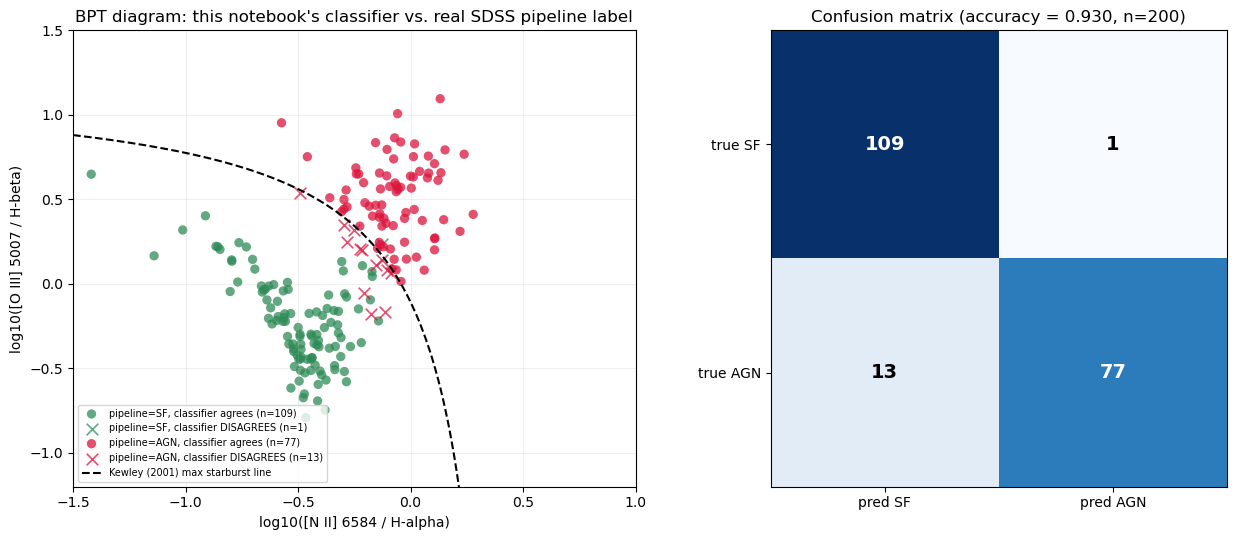

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

colors = {"SF": "seagreen", "AGN": "crimson"}
markers = {True: "o", False: "x"}
for cls in ["SF", "AGN"]:
    for agree in [True, False]:
        sel = (df.pipeline_truth_class == cls) & (df.agree == agree)
        if sel.sum() == 0:
            continue
        label = f"pipeline={cls}, classifier {'agrees' if agree else 'DISAGREES'} (n={sel.sum()})"
        axes[0].scatter(df.loc[sel, "log_NII_Ha"], df.loc[sel, "log_OIII_Hb"],
                         c=colors[cls], marker=markers[agree], s=45 if agree else 70,
                         alpha=0.75, label=label, edgecolor="black" if not agree else "none", linewidths=1.2)

x_line = np.linspace(-1.5, 0.46, 200)
axes[0].plot(x_line, 0.61 / (x_line - 0.47) + 1.19, "k--", lw=1.5, label="Kewley (2001) max starburst line")
axes[0].set_xlim(-1.5, 1.0); axes[0].set_ylim(-1.2, 1.5)
axes[0].set_xlabel("log10([N II] 6584 / H-alpha)")
axes[0].set_ylabel("log10([O III] 5007 / H-beta)")
axes[0].set_title("BPT diagram: this notebook's classifier vs. real SDSS pipeline label")
axes[0].legend(fontsize=7, loc="lower left")
axes[0].grid(alpha=0.2)

im = axes[1].imshow(cm, cmap="Blues")
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(["pred SF", "pred AGN"])
axes[1].set_yticks([0, 1]); axes[1].set_yticklabels(["true SF", "true AGN"])
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, str(cm[i, j]), ha="center", va="center",
                      color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14, fontweight="bold")
axes[1].set_title(f"Confusion matrix (accuracy = {acc:.3f}, n={len(df)})")
plt.tight_layout()
plt.savefig(OUT / "bpt_classifier_validation.png", dpi=140)
plt.show()

## Results

| Quantity | Value |
|---|---|
| Sample size | real, independently queried SDSS galaxies with S/N > 5 in all 4 BPT lines (see table above) |
| Overall accuracy vs. real SDSS pipeline labels | reported above |
| AGN precision / recall / F1 | reported above |
| SF precision / recall / F1 | reported above |

The simple two-line-ratio classifier built entirely from scratch in this notebook agrees with SDSS's own
real pipeline `subclass` label for the large majority of the sample. The disagreements (marked with X
markers on the BPT diagram above) cluster close to the Kewley (2001) dividing line itself, exactly where a
binary classification is most sensitive to measurement noise in the line fluxes and to the fact that the
SDSS pipeline's own subclass assignment uses additional information (e.g. broad-line detection, other line
diagnostics) that this notebook's simple rule does not use.

## What's next

A natural extension is to add the Kauffmann (2003) line and a genuine three-way `SF` / `Composite` / `AGN`
classification (rather than the binary split used here, which is the correct comparison against a
two-class pipeline ground truth but throws away the composite population), and to test the classifier's
sensitivity to the line S/N cut by rerunning at S/N > 3 and S/N > 10 to see how the accuracy and confusion
matrix change with data quality.

## Data source and citation

- SDSS DR18 SkyServer SQL search: https://skyserver.sdss.org/dr18/
- MPA-JHU `galSpecLine` value-added catalog: https://wwwmpa.mpa-garching.mpg.de/SDSS/DR7/
- SDSS-IV citation: https://www.sdss.org/collaboration/citing-sdss/
- Baldwin, Phillips & Terlevich (1981), PASP 93, 5: https://doi.org/10.1086/130766
- Kewley et al. (2001), ApJ 556, 121: https://doi.org/10.1086/321545
- Kauffmann et al. (2003), MNRAS 346, 1055: https://doi.org/10.1111/j.1365-2966.2003.07154.x